**Imports**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import numpy as np
import pathlib
import os
from PIL import Image
import matplotlib.pyplot as plt
import random
import re

Build **CNN**

In [ ]:
IMG_WIDTH = 256
IMG_HEIGHT = 256
image_size = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 64
BUFFER_SIZE = tf.data.AUTOTUNE
SEED = 117

# Define the CNN model
def build_cnn_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1)
    ])
    return model

# Create the model
model = build_cnn_model()
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
#OLD CODE FOR RAM EFFICIENT DATA LOADING

image_dir = "/content/drive/MyDrive/Colab Notebooks/fog/dataset"
num_images = 5860

all_filenames = os.listdir(image_dir)[:num_images]
filepaths = [os.path.join(image_dir, fname) for fname in all_filenames]

labels = []
for fname in all_filenames:
    match = re.findall(r'\d+\.\d+', fname)
    if match:
        labels.append(float(match[0]))
    else:
        # Handle cases where the label isn't found
        labels.append(0.0)  # or raise an error, depending on your use case

dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

def _parse_function(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image, label

dataset = dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.shuffle(buffer_size=num_images)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

history = model.fit(dataset, epochs=10, verbose=1)
"""

Dataset **import**

In [3]:
def load_dataset(image_dir, subset_size=None):

    images = []
    labels = []
    
    filenames = os.listdir(image_dir)
    
    if subset_size:
        filenames = random.sample(filenames, min(subset_size, len(filenames)))
    
    for filename in filenames:
        img = Image.open(os.path.join(image_dir, filename))
        image = np.array(img) / 255.0
        images.append(image)
        label = float(re.findall(r'\d+\.\d+', filename)[0])
        labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

In [4]:
image_dir = "resources/dataset"
images,labels = load_dataset(image_dir)

In [5]:
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=SEED
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - loss: 19.2529 - mae: 1.0852 - val_loss: 0.0241 - val_mae: 0.1240
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0230 - mae: 0.1166 - val_loss: 0.0202 - val_mae: 0.1062
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0227 - mae: 0.1164 - val_loss: 0.0146 - val_mae: 0.0946
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0143 - mae: 0.0926 - val_loss: 0.0188 - val_mae: 0.1010
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0132 - mae: 0.0876 - val_loss: 0.0203 - val_mae: 0.1078
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0136 - mae: 0.0888 - val_loss: 0.0156 - val_mae: 0.0973
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0109 - mae: 0.0802 - val_loss: 0.0146 - val_mae: 0.0905
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0099 - mae: 0.0767 - val_loss: 0.0146 - val_mae: 0.0916
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49m

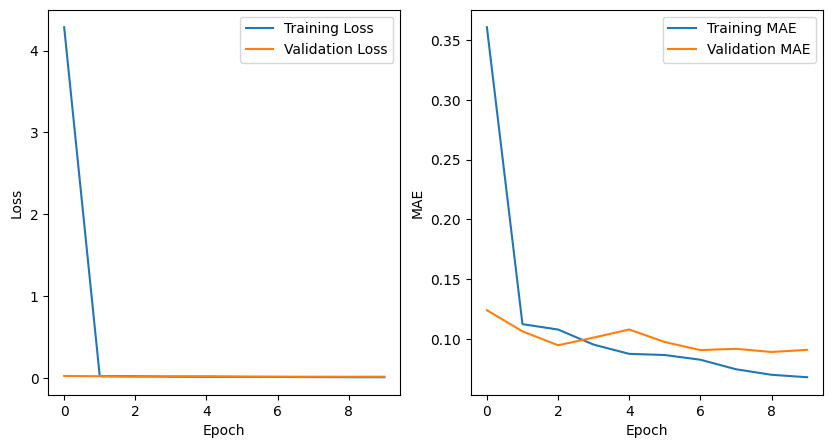

In [ ]:
# Fit the model
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

# Evaluate the model
loss, mae = model.evaluate(test_images, test_labels, verbose=0)
print(f"Mean Absolute Error on test data: {mae}")

# Plot the loss and MAE
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

model_weights_path = "/content/drive/MyDrive/Colab Notebooks/fog/model_weights"
os.makedirs(model_weights_path, exist_ok=True)
model.save_weights(os.path.join(model_weights_path, "fog6000_2.weights.h5"))

In [6]:
model = build_cnn_model()
model.load_weights("resources/model_weights/fog6000_2.weights.h5")

**Display result and test on validation**

In [7]:
image_dir = "resources/dataset"
images_sample,labels_sample = load_dataset(image_dir, subset_size=16)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step


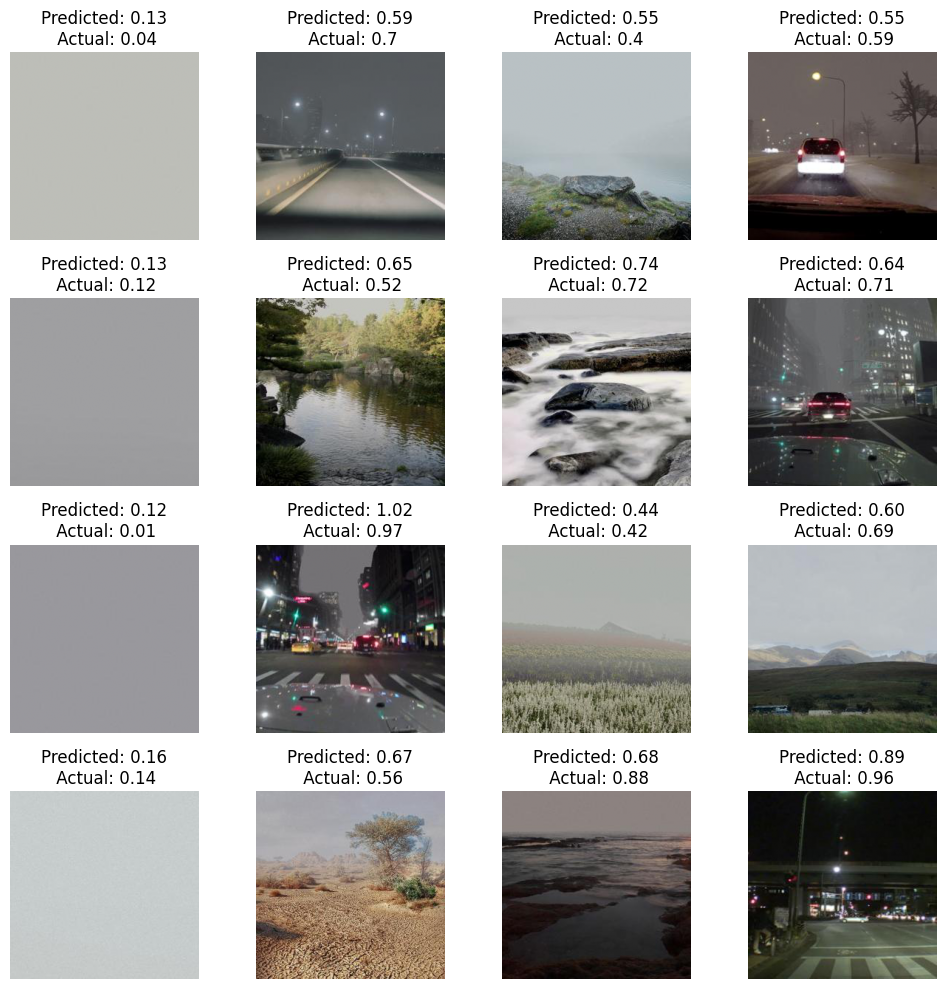

In [8]:
predictions = model.predict(images_sample)
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images_sample[i])
    plt.title(f"Predicted: {predictions[i][0]:.2f}\n Actual: {labels_sample[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


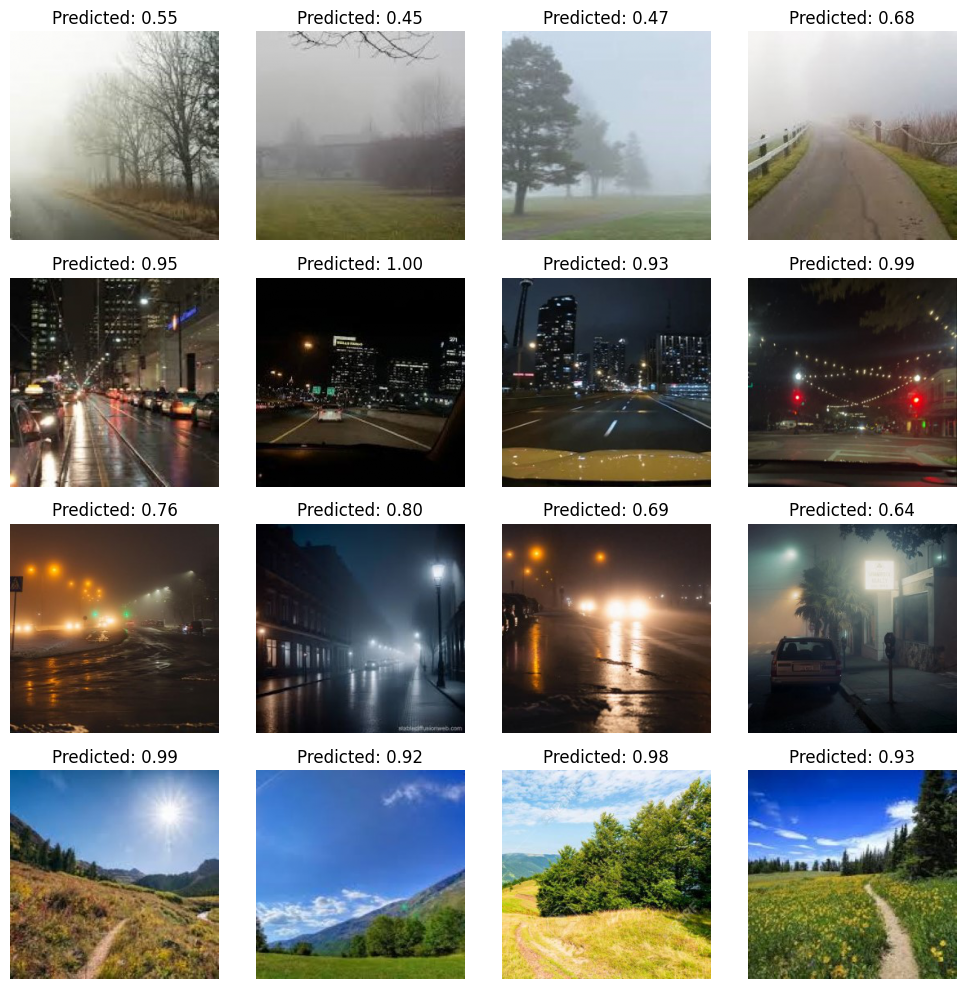

In [9]:
image_dir = "resources/valid"
val_images = []
for filename in os.listdir(image_dir):
        img = Image.open(os.path.join(image_dir, filename))
        image = np.array(img) / 255.0
        val_images.append(image) 
val_images = np.array(val_images)
predictions = model.predict(val_images)
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(val_images[i])
    plt.title(f"Predicted: {predictions[i][0]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()